# JAX-SCM interactive example
Author: Maximilian Pierzyna

<a target="_blank" href="">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

This notebook simulates the GABLS1 stable atmospheric boundary layer case using [JAX-SCM](https://github.com/mpierzyna/jax_scm). JAX-SCM, is an atmospheric single-column model, implemented in Python and JAX, featuring prognostic turbulent kinetic energy and parameterized turbulent statistics from MYNN-2.5.

**WARNING!** 

Only run the `pip install` cell below when executing the notebook on Google Colab!
This command will install JAX-SCM globally! 
On your local machine, it is strongly advised to use `uv` or a different Python virtual environment manager!

In [ ]:
# Install JAX-SCM.
# Pandas is pinned to version 2 because of conflicts with the Colab environment.
# You will likely still see errors. Ignore them.
# RESTART THE RUNTIME AFTER INSTALLATION COMPLETES!
!pip install pandas==2.* git+https://github.com/mpierzyna/jax_scm.git

Everything from here is save to run on any system.

In [ ]:
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from scm.config import Namelist, LogConfig
from scm.convert import get_fc
from scm.grid import StaggeredGrid
from scm.io.local import out_to_ds
from scm.interfaces import Forcing, Simulation
from scm.mo import BusingerDyerAltSimFuncs, MOSettings
from scm.mynn.interfaces import ProgVarsMYNN
from scm.mynn.model import init_model
from scm.time_stepping import simulate

Below we set up the simulation of GABLS 1 following [Cuxart et al. (2006)](https://link.springer.com/article/10.1007/s10546-005-3780-1). **Feel free to play with the settings.** The default setup is as follows:

- Domain: 400m high, 64 vertical levels
- Forcing:
    - Coriolis force at 73 deg latitude
    - Geostrophic wind of 8 m/s
    - Constant surface cooling of 0.25 K/h
- Initial conditions:
    - Initial wind is the same as geostrophic wind
    - Initial temperature is neutral up to inversion height (100m), then stably stratified
    - No moisture
    - TKE decaying with height
- Simulation time: 9h

In [3]:
## Grid
Nz = 64
grid = StaggeredGrid(H=400, Nz=Nz)

## Forcing
# Geostrophic wind
ug = jnp.ones(Nz) * 8.0  # m/s
vg = jnp.zeros(Nz)  # m/s

# Surface temperature forcing
th_s_0 = 265  # K, initial surface temperature
th_s_fn = lambda t_s: th_s_0 - 0.25 * t_s / (60 * 60)  # K, 0.25 K per hour cooling

# No moisture
w_qv_s = lambda t_s: jnp.array(0.0)  # g/kg m/s

forcing = Forcing(
    u_geo=lambda t_s: ug,
    v_geo=lambda t_s: vg,
    f_c=get_fc(lat_deg=73),  # 73 deg N
    th_s=th_s_fn,
    w_qv_s=w_qv_s,
)

# MO settings
mo_settings = MOSettings(
    z0m=0.1,
    z0h=0.1,
    sim_funcs=BusingerDyerAltSimFuncs(gamma_m=16, gamma_h=16, b_m=4.8, b_h=7.8),
)

## Initial conditions
# Initial wind profile
u = jnp.copy(ug)
v = jnp.copy(vg)

# Initial temperature
z_inv = 100
th = jnp.ones(Nz) * 265.0  # K
th = jnp.where(grid.z > z_inv, th + 0.01 * (grid.z - z_inv), th)  # capping inversion

# No moisture
qv = jnp.zeros(grid.Nz)

# Initial TKE
tke = jnp.zeros(grid.Nz)
tke = jnp.where(grid.z < 250, 0.4 * (1 - grid.z / 250) ** 3, tke)  # m^2 s^-2

init = ProgVarsMYNN(u=u, v=v, th=th, qke=2 * tke, qv=qv)

sim = Simulation(
    name="GABLS1",
    grid=grid,
    init=init,
    forcing=forcing,
    mo_settings=mo_settings,
    t_start_s=0,
    t_end_s=9 * 60 * 60,  # simulate for 9h
    th_ref=263.5,  # midpoint of surface cooling range, following microhh GABLS1 case
    t_index_fn=lambda t_s: t_s / 3600,  # hours
)

The initial and boundary conditions from above are visualized here.

/var/folders/ck/57tr_7093z7_08d9rrdhz34sk8mzb1/T/ipykernel_40288/3228795710.py:14: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/var/folders/ck/57tr_7093z7_08d9rrdhz34sk8mzb1/T/ipykernel_40288/3228795710.py:28: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


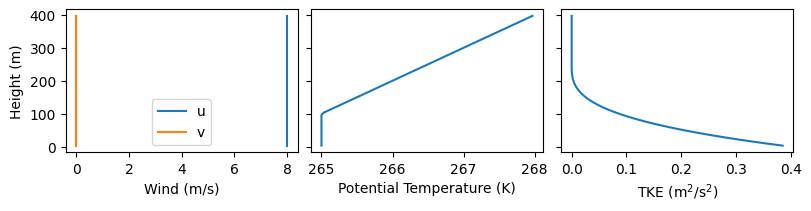

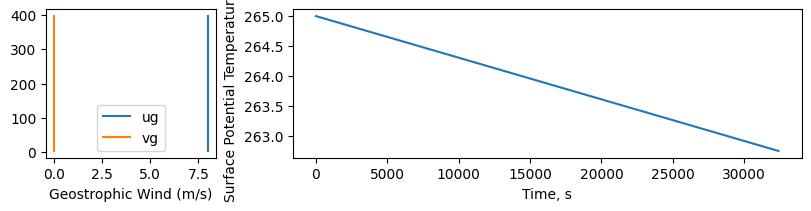

In [4]:
# Initial conditions
fig, axarr = plt.subplots(ncols=3, figsize=(8, 2), sharey="row", layout="constrained")
axarr[0].plot(u, grid.z, label="u")
axarr[0].plot(v, grid.z, label="v")
axarr[0].set_xlabel("Wind (m/s)")
axarr[0].set_ylabel("Height (m)")
axarr[0].legend()

axarr[1].plot(th, grid.z)
axarr[1].set_xlabel("Potential Temperature (K)")

axarr[2].plot(tke, grid.z)
axarr[2].set_xlabel("TKE (m$^2$/s$^2$)")
fig.show()

# Forcing
fig, axarr = plt.subplots(ncols=2, figsize=(8, 2), width_ratios=[1, 3], layout="constrained")
axarr[0].plot(ug, grid.z, label="ug")
axarr[0].plot(vg, grid.z, label="vg")
axarr[0].set_xlabel("Geostrophic Wind (m/s)")
axarr[0].legend()

t = jnp.array([0, 9 * 60 * 60])  # 0 and 9 hours
axarr[1].plot(t, th_s_fn(t))
axarr[1].set_xlabel("Time, s")
axarr[1].set_ylabel("Surface Potential Temperature (K)")

fig.show()

Now, we run the simulation. The `Namelist` object specifies that we use the implicit Crank-Nicholson solver with $\Delta t=1$s time step. The model output is converted to an xarray Dataset.

In [5]:
cfg = Namelist(time_int="implicit", dt_s=1, logging=LogConfig(log_every_n=10))

# Run simulation
model = init_model(sim, cfg=cfg)
out = simulate(model=model, sim=sim, cfg=cfg)

# Convert output to xarray dataset
ds = out_to_ds(out=out, sim=sim)

Simulation started.
t=300 (0%)
t=3300 (9%), this iter: 0.01s, ETA: 0.6s
t=6300 (19%), this iter: 0.00s, ETA: 0.3s
t=9300 (28%), this iter: 0.00s, ETA: 0.3s
t=12300 (37%), this iter: 0.00s, ETA: 0.3s
t=15300 (47%), this iter: 0.00s, ETA: 0.2s
t=18300 (56%), this iter: 0.00s, ETA: 0.2s
t=21300 (65%), this iter: 0.00s, ETA: 0.2s
t=24300 (75%), this iter: 0.01s, ETA: 0.1s
t=27300 (84%), this iter: 0.00s, ETA: 0.1s
t=30300 (93%), this iter: 0.00s, ETA: 0.0s
Total elapsed time: 0.5s
Simulation complete.


In [6]:
# Inspect output dataset
ds

<xarray.Dataset> Size: 685kB
Dimensions:         (time: 109, z: 64, zh: 65)
Coordinates:
  * time            (time) float32 436B 0.0 0.08333 0.1667 ... 8.833 8.917 9.0
  * z               (z) float32 256B 3.125 9.375 15.62 ... 384.4 390.6 396.9
  * zh              (zh) float32 260B 0.0 6.25 12.5 18.75 ... 387.5 393.8 400.0
Data variables: (12/46)
    u               (time, z) float32 28kB ...
    v               (time, z) float32 28kB ...
    th              (time, z) float32 28kB ...
    qv              (time, z) float32 28kB ...
    qke             (time, z) float32 28kB ...
    u_w             (time, zh) float32 28kB ...
    ...              ...
    frc_u_geo       (time, z) float32 28kB ...
    frc_v_geo       (time, z) float32 28kB ...
    frc_th_s        (time) float32 436B ...
    frc_w_qv_s      (time) float32 436B ...
    frc_f_c         float64 8B 0.0001395
    frc_dth_dz_top  float64 8B 0.01
Attributes:
    name:         GABLS1
    t_start_s:    0
    t_end_s:      32400
    th_ref:       263.5
    mo_settings:  sim_funcs: !!python/object:scm.mo.BusingerDyerAltSimFuncs\n...

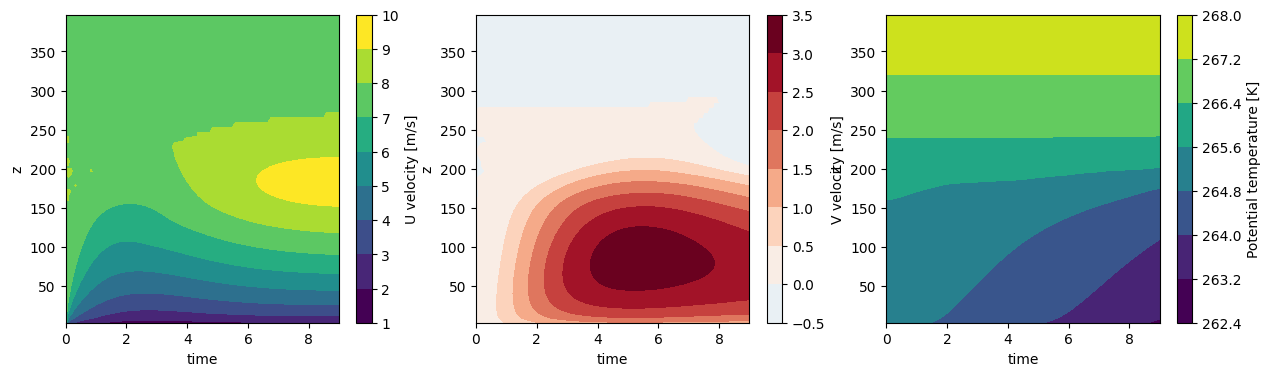

In [7]:
# Time-height plots of wind speed and potential temperature
fig, (ax_u, ax_v, ax_th) = plt.subplots(ncols=3, figsize=(15, 4))

ds["u"].T.plot.contourf(ax=ax_u)
ds["v"].T.plot.contourf(ax=ax_v)
ds["th"].T.plot.contourf(ax=ax_th)

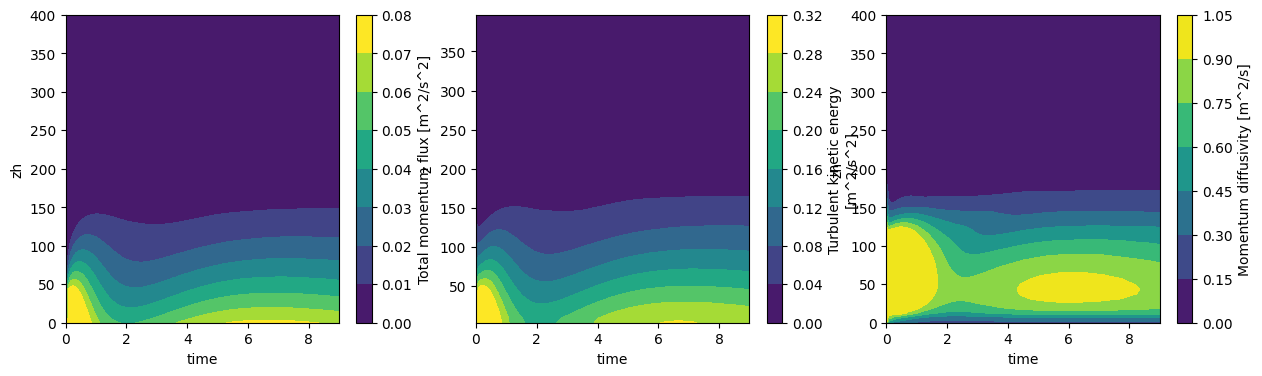

In [8]:
# Time-height plots of total momentum flux, TKE, and eddy diffusivity
fig, (ax_tau, ax_tke, ax_Km) = plt.subplots(ncols=3, figsize=(15, 4))

# Compute total vertical momentum flux
tau = (ds["u_w"] ** 2 + ds["v_w"] ** 2) ** 0.5
tau.attrs["long_name"] = "Total momentum flux"  # for plotting
tau.clip(max=.075).T.plot.contourf(ax=ax_tau)

# Divide by 2 to get TKE from QKE
tke = ds["qke"] / 2
tke.attrs["long_name"] = "Turbulent kinetic energy"  # rename for plotting
tke.clip(max=.3).T.plot.contourf(ax=ax_tke)

# Plot eddy diffusivity
ds["Km"].clip(max=1).T.plot.contourf(ax=ax_Km)

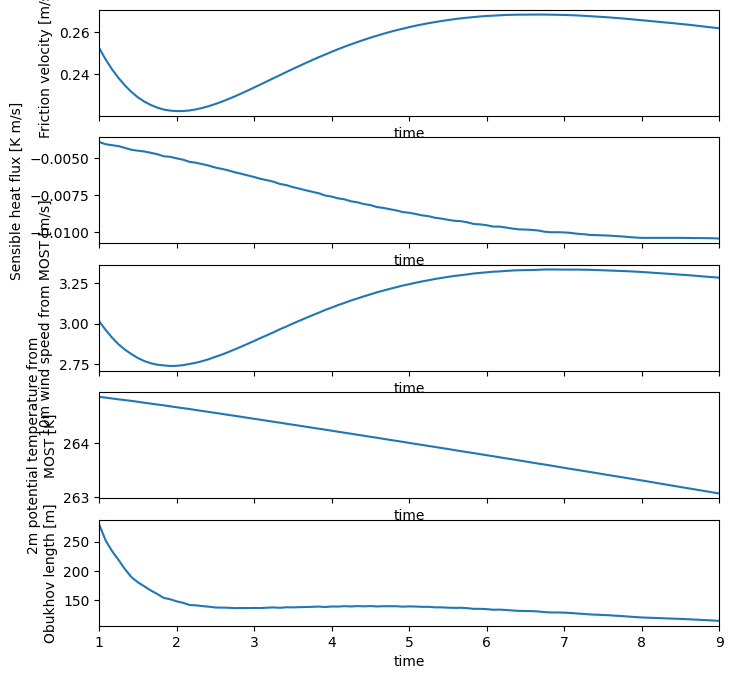

In [9]:
# Time series of diverse surface properties.
# First hour is discarded because of spinup leading to very high u_*.
fig, axarr = plt.subplots(nrows=5, figsize=(8, 8), sharex="col")

sel = {"time": slice(1, None)}  # Discard first hour because of spinup

ds["mo_u_st"].sel(**sel).plot(ax=axarr[0])
ds["mo_w_th"].sel(**sel).plot(ax=axarr[1])
ds["mo_m10"].sel(**sel).plot(ax=axarr[2])
ds["mo_th2"].sel(**sel).plot(ax=axarr[3])
ds["mo_L"].sel(**sel).plot(ax=axarr[4])

for ax in axarr:
    ax.margins(x=0)

/Users/mpierzyna/Nextcloud/Research/09b_jax_scm/jax_scm/.venv/lib/python3.12/site-packages/xarray/computation/apply_ufunc.py:820: RuntimeWarning: divide by zero encountered in log10
  result_data = func(*input_data)


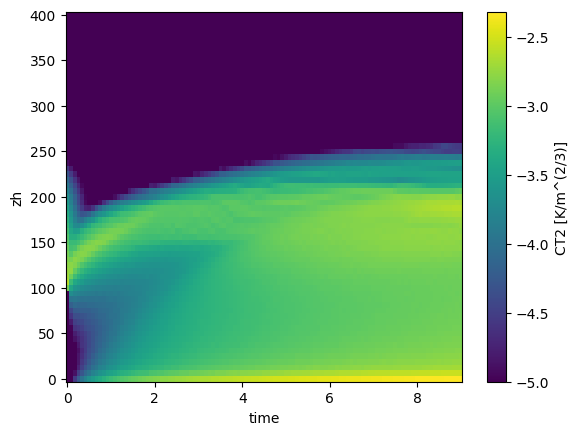

In [10]:
# Diagnosed 2nd-order structure function parameter of potential temperature
np.log10(ds["ct2"]).clip(min=-5).T.plot()